# Probabilidad

### Conceptos basicos

In [1]:
# vamos a calcular probabilidad de tener un numero par al lanzar un dado
# Definimos el espacio muestral y el evento de interes
espacio_muestral = {1, 2, 3, 4, 5, 6} #se pasa un set para evitar duplicados
evento_par = {2, 4, 6}
# Calculamos la probabilidad
probabilidad_par = len(evento_par) / len(espacio_muestral)
print(espacio_muestral)
print(evento_par)
print(f"La probabilidad de obtener un numero par al lanzar un dado es: {probabilidad_par:.2f}")

{1, 2, 3, 4, 5, 6}
{2, 4, 6}
La probabilidad de obtener un numero par al lanzar un dado es: 0.50


### Variables aleatorias

In [ ]:
import matplotlib.pyplot as plt

# Vamos a describir el lanzamiento de una moneda que se lanza, y x =. si sale cara y 0 si sale cruz, x sera la variable alateoria
# Definimos la variable aleatoria y su distribucion de probabilidad

def func_distribucion(x):
    if x < 0:
        return 0 #esta fuera de rango
    elif x < 1:
        return 0.5
    else:
        return 1 

In [3]:
# probabilidad de cara
probabilidad_cara = func_distribucion(1) - func_distribucion(0)
print(f"La probabilidad de obtener cara es: {probabilidad_cara:.2f}")
# probabilidad de cruz
probabilidad_cruz = func_distribucion(0) - func_distribucion(-1)
print(f"La probabilidad de obtener cruz es: {probabilidad_cruz:.2f}")

La probabilidad de obtener cara es: 0.50
La probabilidad de obtener cruz es: 0.50


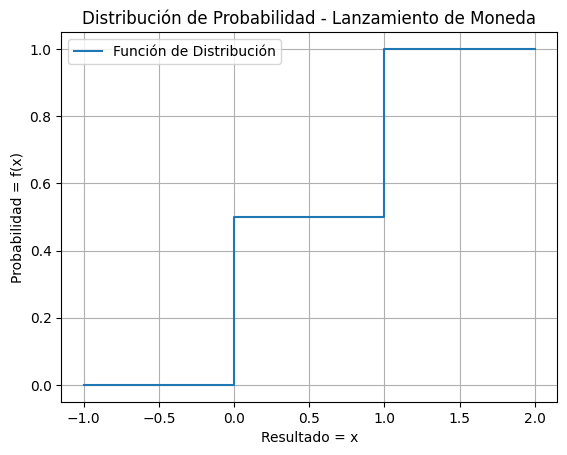

In [9]:
# Si quiero graficar

x_vals = [-1, 0, 1, 2]
y_vals = [func_distribucion(x) for x in x_vals] #lista por compresion

plt.step(x_vals, y_vals, where='post', label='Función de Distribución')
plt.xlabel("Resultado = x")
plt.ylabel("Probabilidad = f(x)")
plt.title("Distribución de Probabilidad - Lanzamiento de Moneda")
plt.legend()
plt.grid()
plt.show()

## Distribucion de Probabilidad

In [10]:
# voy a generar numeros aleatorios
import numpy as np

random_generator = np.random.default_rng(seed=42) #default_rng construye el metodo de generacion de numeros aleatorios.


### Metodo poisson

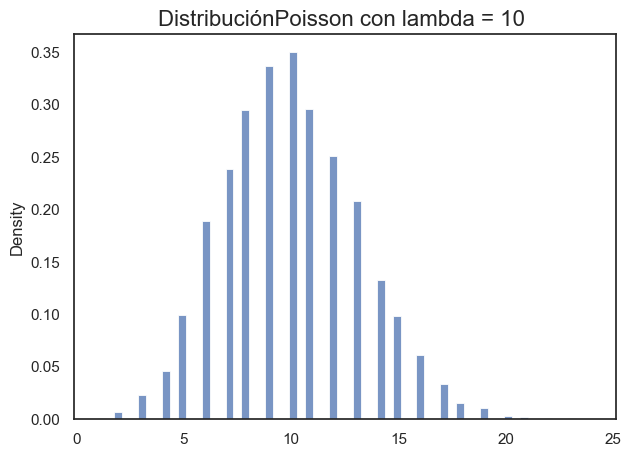

In [15]:
# genero datos con lambda = 10
lambda_value = 10
sample_size = 10000
random_poisson_data10 = random_generator.poisson(lam=lambda_value, size=sample_size)

# grafico datos generados usando distribution plotter
import seaborn as sns
def distribution_plotter(data,label, bins= 'auto'):
    sns.set(rc={"figure.figsize": (7,5)})
    sns.set_style("white")
    dist= sns.histplot(data, bins=bins, stat='density', kde=False, line_kws= {'linewidth': 5}, thresh=None)
    dist.set_title("Distribución" + label + " ", fontsize=16)

distribution_plotter(random_poisson_data10, label="Poisson con lambda = 10")

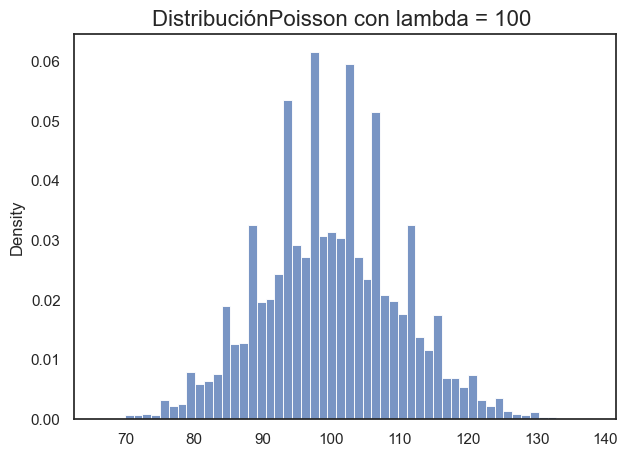

In [16]:
# veo que pasa si lamba aumenta
lambda_value = 100
random_poisson_data100 = random_generator.poisson(lam=lambda_value, size=sample_size)

distribution_plotter(random_poisson_data100, label="Poisson con lambda = 100")

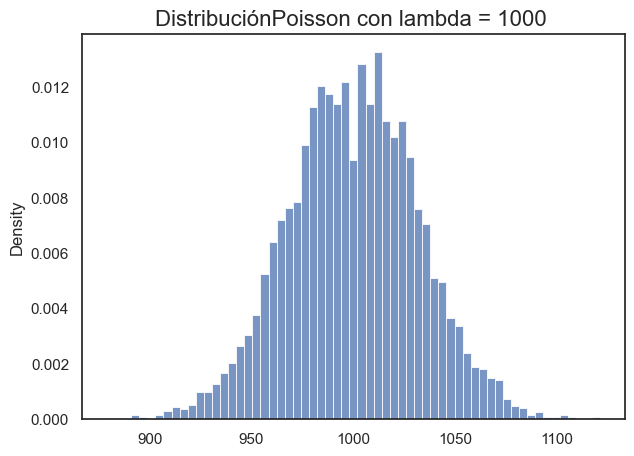

In [19]:
# veo que pasa si lamba aumenta
lambda_value = 1000
random_poisson_data1000 = random_generator.poisson(lam=lambda_value, size=sample_size)

distribution_plotter(random_poisson_data1000, label="Poisson con lambda = 1000")

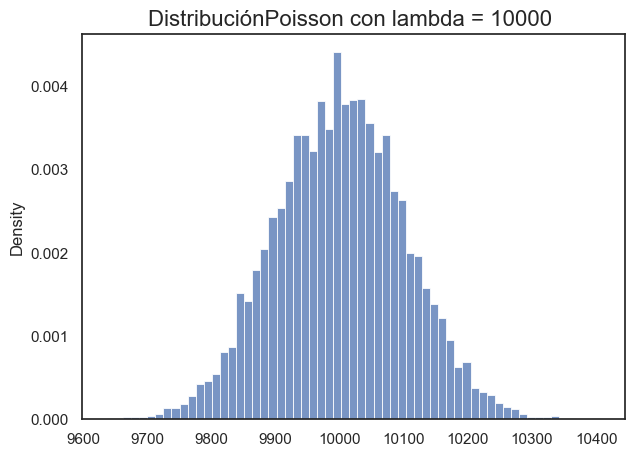

In [21]:
# veo que pasa si lamba aumenta
lambda_value = 10000
random_poisson_data10000 = random_generator.poisson(lam=lambda_value, size=sample_size)

distribution_plotter(random_poisson_data10000, label="Poisson con lambda = 10000")

A medida que aumenta lambda, se hace mas parecida a una campana de gauss, o distribucion normalizada

## Teorema de Bayes

In [23]:
# Un laboratorio quimico va a producir una pruebra para una enfermadad rara
# la prevalencia en la poblacion es del 1%
# si una persona tiene la enfermedad, el test da positivo el 95% de las veces
# si una persona no tiene la enfermedad, el test da positivo el 10% de las veces

# queremos saber cual es la probabilidad de que una persona tenga la enfermedad dado que el test dio positivo
# Definimos las probabilidades conocidas

P_enfermedad = 0.01 # prevalencia de la enfermedad
P_positivo_dado_enfermedad = 0.95 # sensibilidad del test
P_positivo_dado_no_enfermedad = 0.10 # tasa de falsos positivos

#calculo la probabidad de no enfermadad
P_no_enfermedad = 1 - P_enfermedad

#calculo la probabilidad total de obtener un resultado positivo
P_positivo = (P_positivo_dado_enfermedad * P_enfermedad) + (P_positivo_dado_no_enfermedad * P_no_enfermedad)

# Aplico el teorema de Bayes para calcular la probabilidad de tener la enfermedad dado un resultado positivo
P_enfermedad_dado_positivo = (P_positivo_dado_enfermedad * P_enfermedad) / P_positivo

# imprimo el resultado
print(f"La probabilidad de tener la enfermedad dado que el test dio positivo es: {P_enfermedad_dado_positivo:.2%}")
print(f"La probabilidad de obtener un resultado positivo es: {P_positivo:.2%}")

La probabilidad de tener la enfermedad dado que el test dio positivo es: 8.76%
La probabilidad de obtener un resultado positivo es: 10.85%


## Procesos estocasticos

In [ ]:
# Problema de cadena de Markov
# un cliente de un banco puede tener dos estados cada dia, saldo positivo y sado negativo
# la probabilidad de pasar de saldo positivo a saldo positivo es del 80%
# la probabilidad de pasar de saldo positivo a saldo negativo es del 20%
# la probabilidad de pasar de saldo negativo a saldo negativo es del 70%
# la probabilidad de pasar de saldo negativo a saldo positivo es del 30%

# vamos a ver la probabilidad de que el cliente tenga saldo positivo despues de 2 dias, si hoy tiene saldo positivo
# vamos a ver la probabilidad de que el cliente tenga saldo negativo despues de 2 dias, si hoy tiene saldo positivo

# Defino estados y matriz de transicion
estados = ["Positivo", "Negativo"]
matriz_transicion = np.array([[0.8, 0.2], [0.3, 0.7]]) # da las probabilidades de moverme de un estado a otro

# esta inicializada

estado_inicial = np.array([1, 0]) # el cliente empieza con saldo positivo

# Calculo la distribucion de probabilidad despues de 1 dia
estado_despues_1_dia = np.dot(estado_inicial, matriz_transicion)

# Calculo la distribucion de probabilidad despues de 2 dias
estado_despues_2_dias = np.dot(estado_despues_1_dia, matriz_transicion)


# Imprimo los resultados
print(f"Probabilidad de tener saldo positivo despues de 2 dias: {estado_despues_2_dias[0]:.2%}")
print(f"Probabilidad de tener saldo negativo despues de 2 dias: {estado_despues_2_dias[1]:.2%}")

Probabilidad de tener saldo positivo despues de 2 dias: 70.00%
Probabilidad de tener saldo negativo despues de 2 dias: 30.00%


In [26]:
# Ahora vemos que tenga saldo negativo despues de 2 dias, si hoy tiene saldo negativo
estado_inicial_negativo = np.array([0, 1]) # el cliente empieza con saldo negativo

# Calculo la distribucion de probabilidad despues de 1 dia
estado_despues_1_dia_negativo = np.dot(estado_inicial_negativo, matriz_transicion)

# Calculo la distribucion de probabilidad despues de 2 dias
estado_despues_2_dias_negativo = np.dot(estado_despues_1_dia_negativo, matriz_transicion)

# Imprimo los resultados
print(f"Probabilidad de tener saldo positivo despues de 2 dias: {estado_despues_2_dias_negativo[0]:.2%}")
print(f"Probabilidad de tener saldo negativo despues de 2 dias: {estado_despues_2_dias_negativo[1]:.2%}")

Probabilidad de tener saldo positivo despues de 2 dias: 45.00%
Probabilidad de tener saldo negativo despues de 2 dias: 55.00%
